<a href="https://colab.research.google.com/github/alxmzr/Colab/blob/main/BTC_24H_Predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#https://trading-data-analysis.pro/the-trend-is-your-friend-for-your-trading-and-for-neural-prophet-lagged-regressors-part-5-9e9291f636c

In [2]:
!pip install tiingo
!pip install neuralprophet[live] --quiet
!pip install Pandas
!pip install numpy
!pip install ta --upgrade

In [3]:
!pip install yfinance

In [ ]:
# Fix numpy dependency conflict
!pip uninstall numpy -y
!pip install numpy==1.26.4
!pip install --force-reinstall pandas
!pip install --force-reinstall ta

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tif

  Using cached pandas-3.0.2-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 377, in run
    requirement_set = resolver.resolve(
                      ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/resolution/resolvelib/resolver.py", line 95, in resolve
    result = self._result = resolver.resolve(
                            ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_vendor/resolvelib/resolvers.py", line 546, in resolve
    state 

In [5]:
from ta import add_all_ta_features
from ta.utils import dropna
import requests
from datetime import date, datetime, timedelta
import pandas as pd
import numpy as np
from tiingo import TiingoClient
from neuralprophet import NeuralProphet, set_log_level
set_log_level("CRITICAL")
from neuralprophet import set_random_seed
set_random_seed(0)
import matplotlib.pyplot as plt
pd.plotting.register_matplotlib_converters()
%matplotlib inline
from sklearn.metrics import mean_squared_error
import itertools

ERROR:NP.plotly:Importing plotly failed. Interactive plots will not work.
ERROR:NP.plotly:Importing plotly failed. Interactive plots will not work.


In [17]:
import yfinance as yf
import pandas as pd

ticker = 'BTC-USD'
df_hist = yf.download(ticker, period='2y', interval='1d')

if isinstance(df_hist.columns, pd.MultiIndex):
    df_hist.columns = df_hist.columns.get_level_values(0)

df_hist.columns = [c.lower() for c in df_hist.columns]
df_hist = df_hist.reset_index()
df_hist.columns = [c.lower() for c in df_hist.columns]

print(f'Downloaded {len(df_hist)} rows. Columns: {df_hist.columns.tolist()}')

WARNING - (py.warnings._showwarnmsg) - /tmp/ipykernel_13866/3301099581.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_hist = yf.download(ticker, period='2y', interval='1d')

  df_hist = yf.download(ticker, period='2y', interval='1d')

[*********************100%***********************]  1 of 1 completed

Downloaded 731 rows. Columns: ['date', 'close', 'high', 'low', 'open', 'volume']


In [ ]:
config = {
     'api_key': 'e5f6564c2239e6d9724c20e04808f9f5448f0ddb',
     'session': True
}
client = TiingoClient(config)

ticker = 'btcusd'
frequency = '130min'
now = datetime.now()
end_date = now + timedelta(days=1)
history = client.get_crypto_price_history([ticker],
          endDate = end_date,
          resampleFreq = frequency)

# BTC price data
df_hist = pd.DataFrame.from_dict(history[0]['priceData'])

In [ ]:
# Clean NaN values
df_hist = dropna(df_hist)

# Add all ta features to BTC dataframe
df_hist = add_all_ta_features(df_hist, open="open", high="high", low="low", close="close", volume="volume")

In [ ]:
# Clean NaN values
df_hist = dropna(df_hist)

# Add all ta features to BTC dataframe
df_hist = add_all_ta_features(df_hist, open="open", high="high", low="low", close="close", volume="volume")

In [ ]:
# set up the input data for Neural Prophet with the lagged regressor.

df = pd.DataFrame(df_hist, columns=['date', 'close', 'volume_cmf'])
df.rename(columns = {'date':'ds', 'close':'y'}, inplace = True)
df["ds"] = df["ds"].astype("datetime64[ns]")

# inspect the input dataframe
df.info()

In [8]:
# Process for NeuralProphet
from ta.utils import dropna
from ta import add_all_ta_features

# Add all ta features
df_hist = dropna(df_hist)
df_hist = add_all_ta_features(df_hist, open="open", high="high", low="low", close="close", volume="volume")
df_hist = dropna(df_hist)

df = pd.DataFrame(df_hist, columns=['date', 'close', 'volume_cmf'])
df.rename(columns = {'date':'ds', 'close':'y'}, inplace = True)

# Fix: remove timezone info
df["ds"] = pd.to_datetime(df["ds"]).dt.tz_localize(None)
df = df.dropna(subset=['volume_cmf'])
df = df.iloc[19:]

print("Dataframe 'df' recreated successfully.")
display(df.head())

Dataframe 'df' recreated successfully.


,ds,y,volume_cmf


In [ ]:
print("Checking for NaNs in volume_cmf:")
print(df['volume_cmf'].head(20))

# Drop rows where the indicator hasn't calculated yet (CMF usually needs 20 periods)
df = df.dropna(subset=['volume_cmf'])
print("\nShape after dropping NaNs:", df.shape)

In [ ]:
df = df.iloc[19:]

In [ ]:
# instantiate the model with parameters derived from previous testing and tuning
m = NeuralProphet(
    n_forecasts = 11,
    n_lags = 16,
    learning_rate = 0.01,
    n_changepoints = 90,
    changepoints_range = 0.95,
    trend_reg = 1,
)
# add the regressor to the model
m = m.add_lagged_regressor(names='volume_cmf')

In [ ]:
# Instantiate the model with specified parameters
m = NeuralProphet(
    n_forecasts=11,
    n_lags=16,
    learning_rate=0.01,
    n_changepoints=90,
    changepoints_range=0.95,
    trend_reg=1,
)

# Add the lagged regressor
m = m.add_lagged_regressor(names='volume_cmf')

# Split the data and fit the model
# Frequency is set to 60min to match the yfinance hourly download
df_train, df_test = m.split_df(df, valid_p=0.15)
metrics_train = m.fit(df_train, validation_df=df_test, freq='60min', progress='plot-all')
print(metrics_train.tail())

In [1]:
# 24 hour forecast from hourly data
bars_ahead_forecast = 24

In [ ]:
# instantiate a new model
m = NeuralProphet(
    n_forecasts = 11,
    n_lags = 16,
    learning_rate = 0.01,
    n_changepoints = 90,
    changepoints_range = 0.95,
    trend_reg = 1,
)
m = m.add_lagged_regressor(names='volume_cmf')

In [19]:
from ta.volume import ChaikinMoneyFlowIndicator
import pandas as pd
import numpy as np
from neuralprophet import NeuralProphet

# 1. Manual Indicator Calculation to avoid 'add_all_ta_features' issues
df_prep = df_hist.copy()

# Ensure we have the required columns in lowercase
indicator_cmf = ChaikinMoneyFlowIndicator(
    high=df_prep['high'],
    low=df_prep['low'],
    close=df_prep['close'],
    volume=df_prep['volume'],
    window=20
)
df_prep['volume_cmf'] = indicator_cmf.chaikin_money_flow()

# 2. Build the NeuralProphet dataframe
df = pd.DataFrame()
df['ds'] = pd.to_datetime(df_prep['date']).dt.tz_localize(None)
df['y'] = df_prep['close']
df['volume_cmf'] = df_prep['volume_cmf']

# Drop rows where CMF is NaN (first 19 rows)
df = df.dropna()

print(f'Data points available for training: {len(df)}')

if len(df) > 50:
    m = NeuralProphet(
        n_forecasts=11,
        n_lags=16,
        learning_rate=0.01,
        n_changepoints=90,
        changepoints_range=0.95,
        trend_reg=1,
    )
    m = m.add_lagged_regressor(names='volume_cmf')
    metrics = m.fit(df, freq='D')
    future = m.make_future_dataframe(df, periods=30, n_historic_predictions=len(df))
    forecast = m.predict(future)
    predict = forecast.tail(50)

    std = predict['yhat1'].std()
    upper2 = predict['yhat1'] + (2 * std)
    lower2 = predict['yhat1'] - (2 * std)
    actual = predict['y']
    fcst = predict['yhat1']
    trend = predict['trend']
    dates = predict['ds']
    print('Forecast generated successfully.')
else:
    print('Error: Still not enough data points. Check columns:', df_prep.columns)

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:464: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  if df.groupby("ID").apply(lambda x: x.duplicated("ds").any()).any():

  if df.groupby("ID").apply(lambda x: x.duplicated("ds").any()).any():

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warning

Data points available for training: 712


Training: 0it [00:00, ?it/s]

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alte

Predicting: 22it [00:00, ?it/s]

Forecast generated successfully.


In [ ]:
# Set up the chart data. Add 2 standard deviation lines for possible use in the plot
std = predict['yhat1'].std()
upper2 = predict['yhat1'] + (2 * std)
lower2 = predict['yhat1'] - (2 * std)
actual = predict['y']
fcst = predict['yhat1']
trend = predict['trend']
dates = predict['ds']

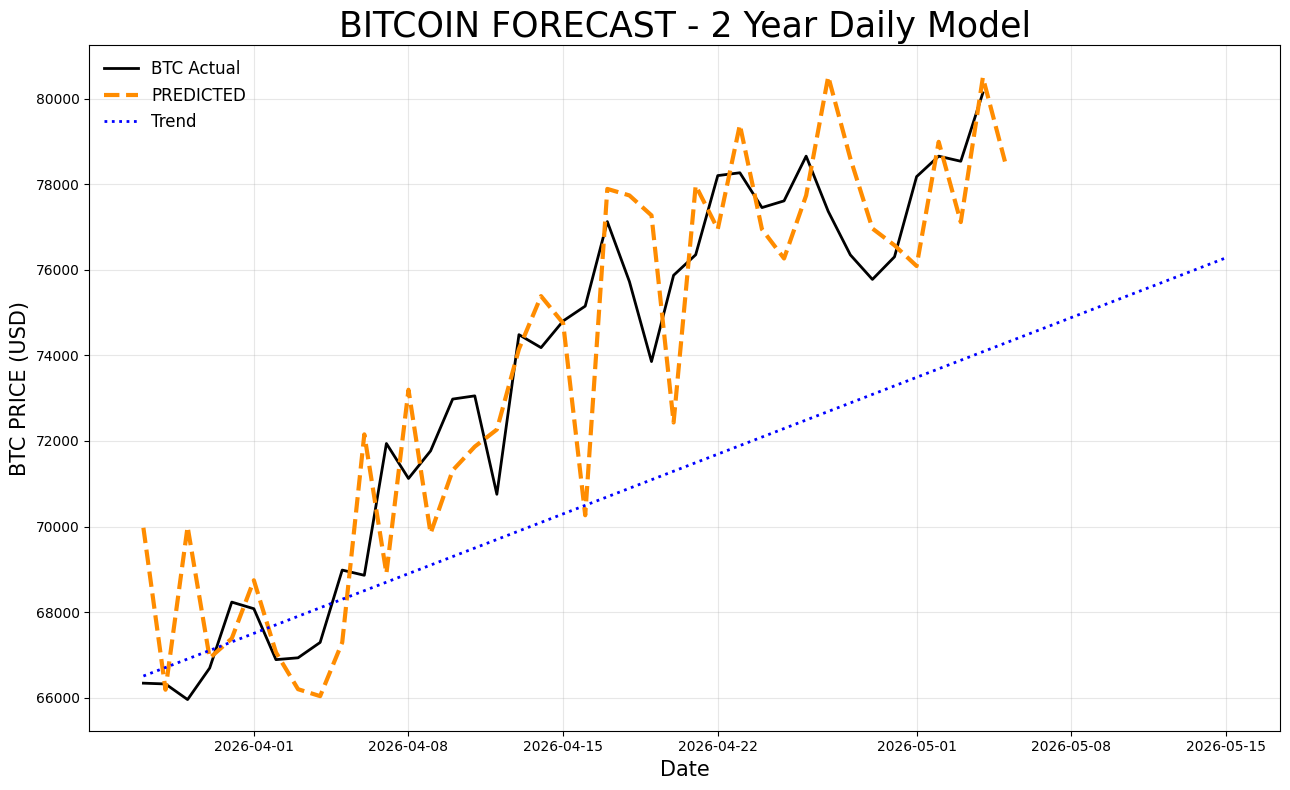

In [21]:
import matplotlib.pyplot as plt

# Ensure we are using the variables from the successful forecast
x = dates
y2 = actual
y3 = fcst
y5 = trend

fig = plt.figure(figsize=(13, 8))
plt.title('BITCOIN FORECAST - 2 Year Daily Model', fontsize=25)
plt.xlabel('Date', fontsize=15)
plt.ylabel('BTC PRICE (USD)', fontsize=15)

plt.plot(x, y2, linewidth=2, color='black', label='BTC Actual')
plt.plot(x, y3, '--', linewidth=3, color='darkorange', label='PREDICTED')
plt.plot(x, y5, ':', linewidth=2, color='blue', label='Trend')

plt.legend(frameon=False, loc='upper left', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Model Performance Evaluation
We can look at the final training metrics to evaluate how well the model fit the historical data.

In [22]:
# Display the last metrics for RMSE and MAE
performance_metrics = metrics.iloc[-1][['RMSE', 'MAE']]
print("Final Training Metrics:")
display(performance_metrics)

# Calculate RMSE specifically on the forecast period if possible
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Filter for rows where we have both actual and predicted values in the tail
mask = predict['y'].notnull() & predict['yhat1'].notnull()
eval_df = predict[mask]

if not eval_df.empty:
    test_rmse = np.sqrt(mean_squared_error(eval_df['y'], eval_df['yhat1']))
    test_mae = mean_absolute_error(eval_df['y'], eval_df['yhat1'])
    print(f"\nEvaluation on the last {len(eval_df)} days:")
    print(f"RMSE: {test_rmse:.2f}")
    print(f"MAE: {test_mae:.2f}")

Final Training Metrics:


,129
RMSE,4623.156738
MAE,3563.965088



Evaluation on the last 39 days:
RMSE: 1996.50
MAE: 1591.25
